In [189]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from sklearn.datasets import make_classification, make_circles, make_moons
from torch import nn, optim
from tqdm.auto import tqdm
import numpy as np

In [396]:
def get_data(n_samples):
    # x, y = make_classification(
    #     n_samples=n_samples,
    #     n_features=2,
    #     n_informative=2,
    #     n_redundant=0,
    #     n_repeated=0,
    #     random_state=1,
    #     flip_y=0.1,
    #     n_clusters_per_class=1,
    # )
    # x, y = make_circles(n_samples, noise=0.1, factor=0.5, random_state=42)
    x, y = make_moons(n_samples, noise=0.15, random_state=42)
    return torch.tensor(x).float(), torch.tensor(y).long()

In [375]:
def get_data(n_samples=1000, noise=0.8, random_state=42):
    np.random.seed(random_state)

    # n = np.sqrt(np.random.rand(n_samples // 2)) * 780 * (2 * np.pi) / 360
    n = np.sqrt(np.random.rand(n_samples // 2)) * 540 * (2 * np.pi) / 360
    d1x = -np.cos(n) * (n + np.random.randn(n_samples // 2) * noise)
    d1y = np.sin(n) * (n + np.random.randn(n_samples // 2) * noise)
    X = np.vstack((np.column_stack((d1x, d1y)), np.column_stack((-d1x, -d1y))))
    y = np.hstack((np.zeros(n_samples // 2), np.ones(n_samples // 2)))

    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

In [437]:
n_train = 500
x_all, y_all = get_data(1000 + n_train)
idx = torch.randperm(len(y_all), generator=torch.Generator().manual_seed(42))
x_all = x_all[idx]
y_all = y_all[idx]

x, x_t = torch.split(x_all, [n_train, 1000])
y, y_t = torch.split(y_all, [n_train, 1000])

flip_frac = 0.2
flip_idx = torch.randperm(len(y), generator=torch.Generator().manual_seed(42))[:int(flip_frac * len(y))]
y[flip_idx] = 1 - y[flip_idx]

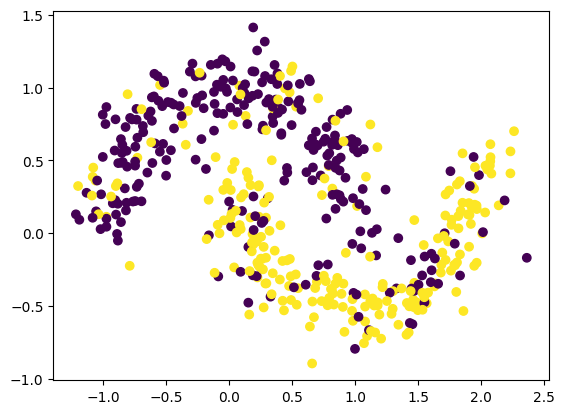

In [438]:
plt.scatter(x[:, 0], x[:, 1], c=y)

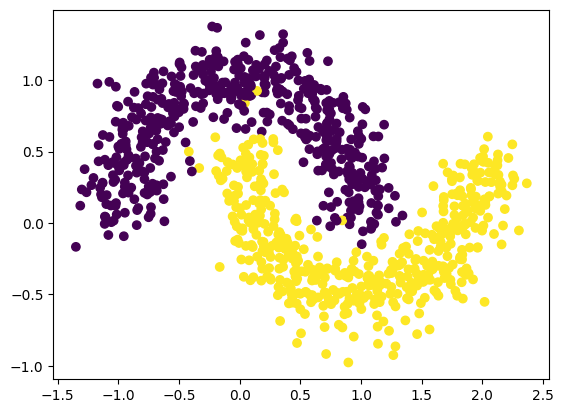

In [439]:
plt.scatter(x_t[:, 0], x_t[:, 1], c=y_t)

In [440]:
class MLP(nn.Module):
    def __init__(self, h):
        super().__init__()
        self.fc1 = nn.Linear(2, h)
        self.fc = nn.Linear(h, h)
        self.fc2 = nn.Linear(h, 1)

    def forward(self, x):
        return self.fc2(F.relu(self.fc(F.relu(self.fc1(x)))))

In [441]:
class Ens(nn.Module):
    def __init__(self, nets):
        super().__init__()
        self.nets = nn.ModuleList(nets)

    def forward(self, x):
        outs = []
        for net in self.nets:
            out = net(x)
            outs.append(out)
        return torch.stack(outs).mean(0)

  0%|          | 0/20 [00:00<?, ?it/s]

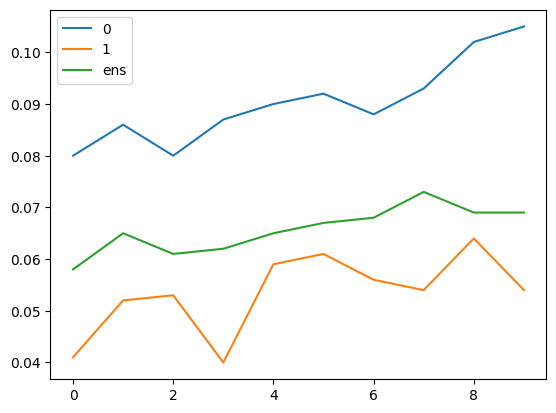

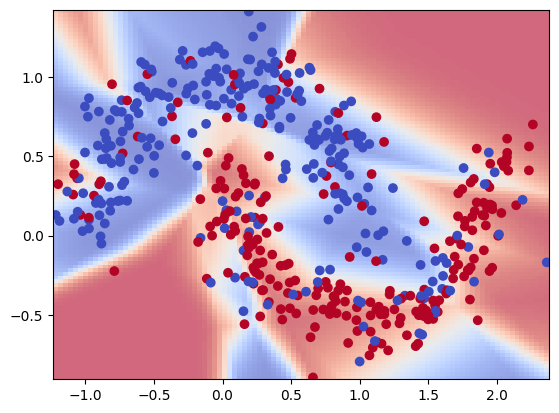

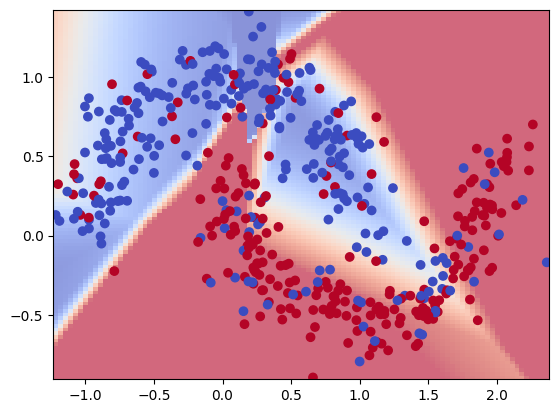

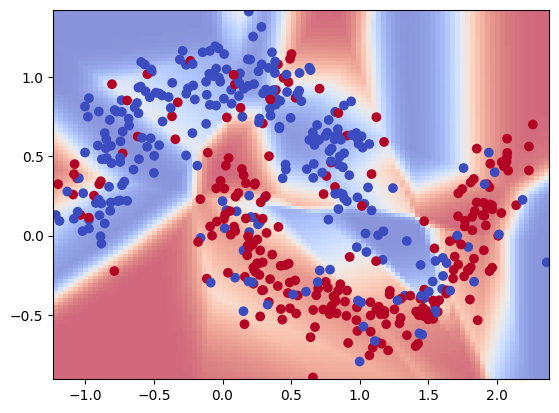

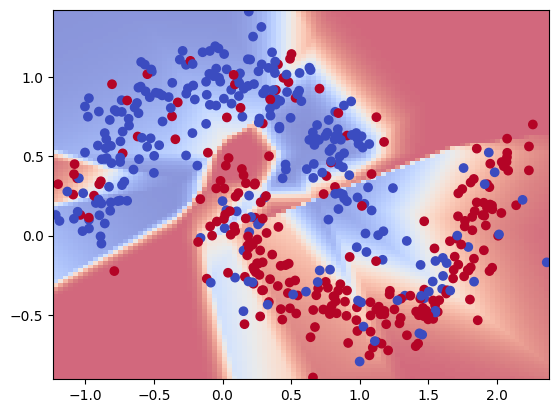

------------------------


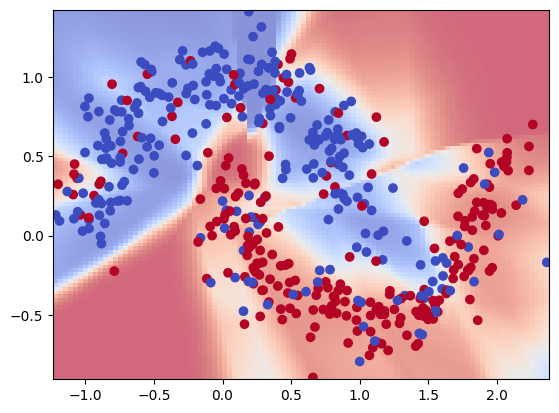

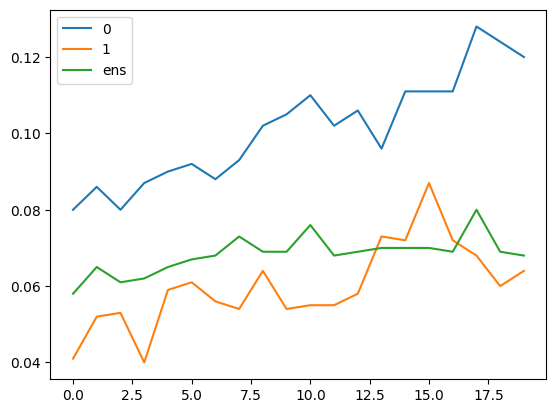

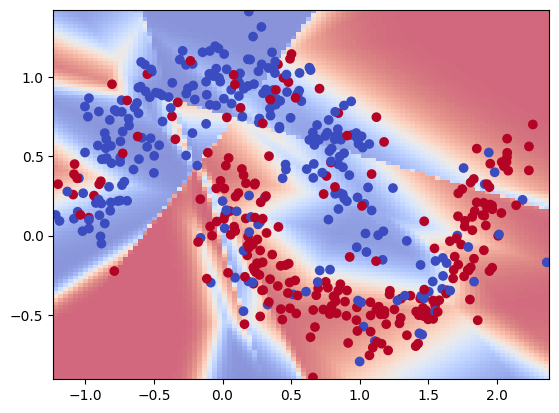

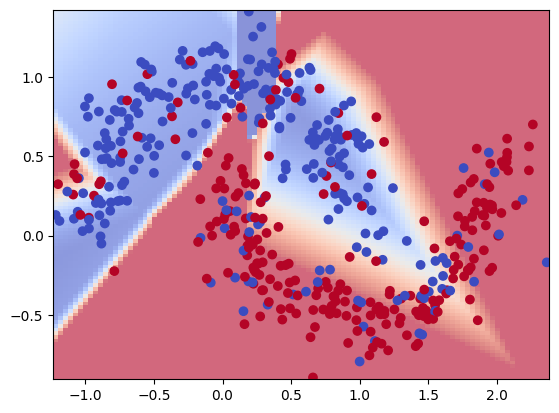

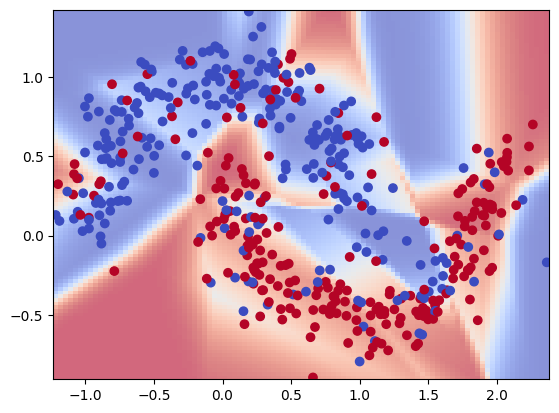

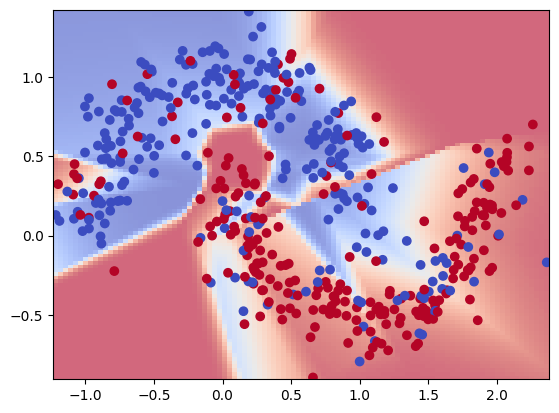

------------------------


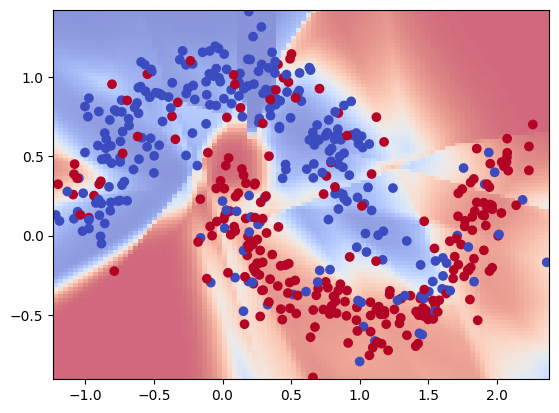

In [448]:
nets = [MLP(10).to("cuda") for _ in range(4)]
opts = [optim.Adam(net.parameters(), lr=0.1) for net in nets]

x = x.to("cuda")
y = y.to("cuda")
x_t = x_t.to("cuda")
y_t = y_t.to("cuda")

errs = [[] for _ in nets]
ens_errs = []
for epoch in tqdm(range(20)):
    for net, opt in zip(nets, opts):
        p = torch.randperm(len(x))
        x = x[p]
        y = y[p]
    
        for bx, by in zip(torch.split(x, 1), torch.split(y, 1)):
            opt.zero_grad()
            yhat = net(x)
            loss = F.binary_cross_entropy_with_logits(yhat, y[:, None].float())
            loss.backward()
            opt.step()

    with torch.no_grad():
        yhats = []
        for i, net in enumerate(nets):
            yhat_t = net(x_t)
            yhats.append(yhat_t)
            err = ((yhat_t[:,0] >= 0) != y_t).float().mean()
            errs[i].append(err.item())
        yhat = torch.cat(yhats, dim=-1).mean(-1)
        err = ((yhat >= 0) != y_t).float().mean()
        ens_errs.append(err.item())

    if epoch % 10 == 9:
        plt.plot(errs[0], label="0")
        plt.plot(errs[1], label="1")
        plt.plot(ens_errs, label="ens")
        plt.legend()
        plt.show() 
        
        for net in nets:
            viz(net, x, y)
            plt.show()
        print("------------------------")
        viz(Ens(nets), x, y)
        plt.show()

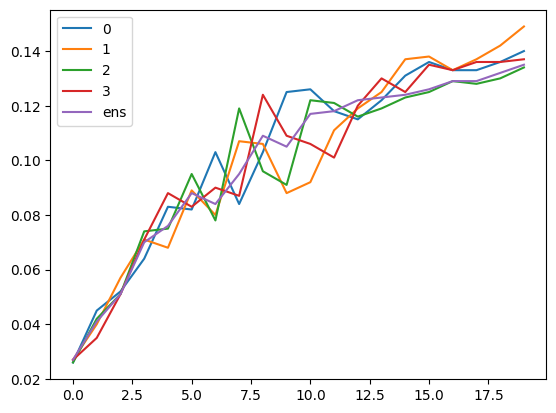

In [445]:
plt.plot(errs[0], label="0")
plt.plot(errs[1], label="1")
plt.plot(errs[2], label="2")
plt.plot(errs[3], label="3")
plt.plot(ens_errs, label="ens")
plt.legend()
plt.show()

In [299]:
def viz(net, x, y, x_min=-5, steps=100):
    x_min = x[:, 0].min()
    x_max = x[:, 0].max()
    y_min = x[:, 1].min()
    y_max = x[:, 1].max()
    xx = torch.linspace(x_min, x_max, steps)
    yy = torch.linspace(y_min, y_max, steps)
    xg, yg = torch.meshgrid(xx, yy)
    inp = torch.stack([xg.reshape(-1), yg.reshape(-1)], dim=-1).to("cuda")
    with torch.no_grad():
        pg = F.sigmoid(net(inp).detach().cpu().view(steps, steps))

    plt.pcolormesh(xg, yg, pg, cmap="coolwarm", alpha=0.6)

    x = x.cpu().numpy()
    plt.scatter(x[:, 0], x[:, 1], c=y.cpu().numpy(), cmap="coolwarm")

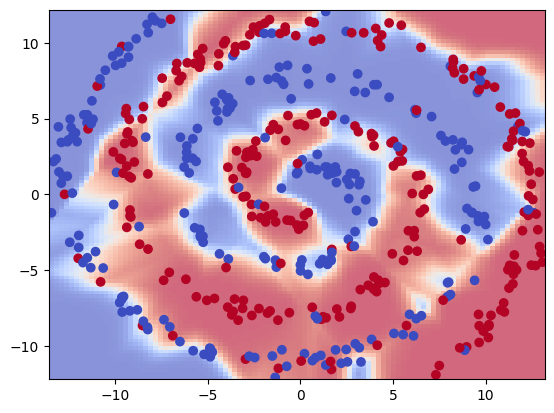

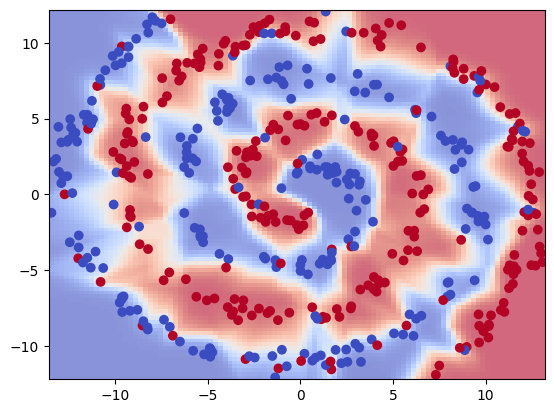

------------------------


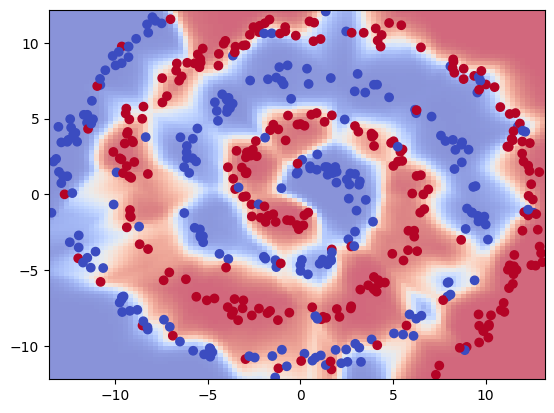

In [245]:
for net in nets:
    viz(net, x, y)
    plt.show()
print("------------------------")
viz(Ens(nets), x, y)